
![GettingStarted](https://mooc-styleguide.s3.amazonaws.com/MOOC-Styles/Active+Learning+Headers/Links/ALH_GettingStarted.png)
#[Step 1] **READ**: Sentiment Analysis with RNN, LSTM and Attention

# **Introduction**
In this notebook, we will learn how to use different models (RNN, LSTM, and Attention) to do the sentiment analysis based on financial sentences from financial news. We will also add the attention layer to the above models and see how results improve. Our computer will be able to predict the sentiment of some sentences-positive, negative, or neutral. And the results could be helpful for governments to make policies, for companies to make decisions, and so on.

Please make sure you download the following news data file and the pre-trained word embedding data file, and then upload them to your google drive/AIEB/ folder.

[news_data.csv](https://drive.google.com/file/d/1ku9m2znUs5eTEf3PqZeuOq-09BRz0QSg/view?usp=share_link)

[glove.6B.100d.txt](https://drive.google.com/file/d/16KiCayf6EpvcRLvqIBBkm3NRQkTvZIUG/view)





#[Step 2] **RUN**: Setting Up the Colab Environment

**Importing Packages**

Python packages enable different functions, providing easy ways of manipulating data and building models. As a first step, we 'import' packages to set up our environment in a way that allows us to take advantage of different capabilities.

Import the necessary libraries.

In [2]:
# !python --version

In [3]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

import tensorflow as tf
from tensorflow.keras import layers


from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Embedding
from tensorflow.keras.models import Sequential


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


/Users/piyush/workspace/projects/DeepLearning/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /Users/piyush/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/Users/piyush/workspace/projects/DeepLearning/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [4]:
# Setting Random Seed to Control Random Start Value for Easier Model Performance Comparison
seed_value = 100

################### also add this one to make sure the consistent.
tf.random.set_seed(seed_value)
###################

tf.keras.utils.set_random_seed(seed_value)
tf.config.experimental.enable_op_determinism()

Now we will set our path for Google Drive in order to read dataset via Google Drive.

In [5]:
## Mount Google Drive Data (If using Google Colaboratory)
# try:
#     from google.colab import drive
#     drive.mount('/content/drive/')
# except:
#     print("Mounting Failed.")

Next, we will set up the semantic library for our model. In our example, we will use a pre-trained library named glove.6B.100d.txt. In this step, we will convert words to vectors so that computer could understand the words in a digital way.

In [6]:
words = []
embeddings = []

with open('/Users/piyush/workspace/projects/DeepLearning/week6/glove.6B.100d.txt', 'r') as f:
    for line in tqdm(f, total=400_000):
        word, *vector = line.split()
        words.append(word)
        embeddings.append(vector)

100%|██████████| 400000/400000 [00:02<00:00, 137350.83it/s]


In [7]:
words[0]

'the'

In [8]:
embeddings[0]

['-0.038194',
 '-0.24487',
 '0.72812',
 '-0.39961',
 '0.083172',
 '0.043953',
 '-0.39141',
 '0.3344',
 '-0.57545',
 '0.087459',
 '0.28787',
 '-0.06731',
 '0.30906',
 '-0.26384',
 '-0.13231',
 '-0.20757',
 '0.33395',
 '-0.33848',
 '-0.31743',
 '-0.48336',
 '0.1464',
 '-0.37304',
 '0.34577',
 '0.052041',
 '0.44946',
 '-0.46971',
 '0.02628',
 '-0.54155',
 '-0.15518',
 '-0.14107',
 '-0.039722',
 '0.28277',
 '0.14393',
 '0.23464',
 '-0.31021',
 '0.086173',
 '0.20397',
 '0.52624',
 '0.17164',
 '-0.082378',
 '-0.71787',
 '-0.41531',
 '0.20335',
 '-0.12763',
 '0.41367',
 '0.55187',
 '0.57908',
 '-0.33477',
 '-0.36559',
 '-0.54857',
 '-0.062892',
 '0.26584',
 '0.30205',
 '0.99775',
 '-0.80481',
 '-3.0243',
 '0.01254',
 '-0.36942',
 '2.2167',
 '0.72201',
 '-0.24978',
 '0.92136',
 '0.034514',
 '0.46745',
 '1.1079',
 '-0.19358',
 '-0.074575',
 '0.23353',
 '-0.052062',
 '-0.22044',
 '0.057162',
 '-0.15806',
 '-0.30798',
 '-0.41625',
 '0.37972',
 '0.15006',
 '-0.53212',
 '-0.2055',
 '-1.2526',
 '0.0

In [9]:
embeddings = np.float32(np.array(embeddings))
embeddings.shape

(400000, 100)

In [10]:
embeddings = np.concatenate([np.zeros((2, 100)),
                            embeddings], axis=0)

In [11]:
word2idx = {w: i+2 for i, w in enumerate(words)}
idx2word = {i+2: w for i, w in enumerate(words)}

word2idx['PAD'] = 0
idx2word[0] = 'PAD'

word2idx['OOV'] = 1
idx2word[1] = 'OOV'


**Loading dataset**
<br>
We then import our dataset, which is stored in the .csv file named ‘news_data.csv’. This data is intended for advancing financial sentiment analysis research. It's two datasets (FiQA, Financial PhraseBank) combined into one easy-to-use CSV file. It provides financial sentences with sentiment labels.


This is done using the pandas library, and the data is stored in a dataframe named df.
1. We then construct a disctory to convert sentiment to digital numbers for convenience.
2. Next, we will make all letters in lower case.
3. In this step, we will convert each sentence to a list of words.
4. After doing all the steps above, we will use our semantic library to convert each comment to a vector.

**Go to your Google Drive and create the folder AIEB, and upload your .csv file under this folder.**

In [12]:

df = pd.read_csv('/Users/piyush/workspace/projects/DeepLearning/week6/news_data.csv')
print(df.iloc[0,0])
print(df.iloc[0,1])

The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .
positive


In [13]:
keys = np.unique(df.Sentiment)
values = list(range(len(keys)))
label_mapper = dict(zip(keys, values))
label_mapper

{'negative': 0, 'neutral': 1, 'positive': 2}

In [14]:
df.Sentiment = df.Sentiment.map(label_mapper)
df.Sentence = df.Sentence.apply(lambda x: x.lower())
df.head()

,Sentence,Sentiment
0,the geosolutions technology will leverage bene...,2
1,"$esi on lows, down $1.50 to $2.50 bk a real po...",0
2,"for the last quarter of 2010 , componenta 's n...",2
3,according to the finnish-russian chamber of co...,1
4,the swedish buyout firm has sold its remaining...,1


In [15]:
df.Sentence = df.Sentence.apply(lambda x: word_tokenize(x))
df.head()

,Sentence,Sentiment
0,"[the, geosolutions, technology, will, leverage...",2
1,"[$, esi, on, lows, ,, down, $, 1.50, to, $, 2....",0
2,"[for, the, last, quarter, of, 2010, ,, compone...",2
3,"[according, to, the, finnish-russian, chamber,...",1
4,"[the, swedish, buyout, firm, has, sold, its, r...",1


In [16]:
len(df.iloc[0,0])

32

In [17]:
def indexing_fn(tokens):
    idxs = []
    for token in tokens:
        idxs.append(word2idx.get(token, word2idx['OOV']))
    return idxs

In [18]:
df.Sentence = df.Sentence.apply(indexing_fn)
df.head()

,Sentence,Sentiment
0,"[2, 1, 734, 45, 10746, 1, 11, 14652, 4802, 23,...",2
1,"[82, 80988, 15, 9831, 3, 137, 82, 17310, 6, 82...",0
2,"[12, 2, 78, 550, 5, 657, 3, 1, 11, 1052, 528, ...",2
3,"[202, 6, 2, 1, 3198, 5, 2304, 3, 66, 2, 226, 9...",1
4,"[2, 2794, 11551, 1003, 33, 921, 49, 1528, 3179...",1


In [19]:
len(df.iloc[0,0])

32

**Split the dataset for model**

First, to fit the data into any neural network, we need to convert the data into sequence matrices. For this, we are using the pad_sequence module from keras.preprocessing.

Then, similarly to the past, we will split out dataset to different groups for training. This time, we have training dataset, validation dataset, and test dataset. We set upthe porpotion as 64%, 16%, 20%.

In [20]:
padded_idx = tf.keras.preprocessing.sequence.pad_sequences(df.Sentence,
                                                          maxlen=128,
                                                          padding='post',
                                                          truncating='post')

In [21]:
X_train, X_test = train_test_split(padded_idx, test_size=0.2, shuffle=True, random_state=0, stratify=df.Sentiment)
y_train, y_test = train_test_split(df.Sentiment, test_size=0.2, shuffle=True, random_state=0, stratify=df.Sentiment)

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, shuffle=True, random_state=0)

#[Step 3] **RUN**: Setting Up the Neural Network Architecture

**Design the simple recurrent neural network architecture**


1. First, we instantiate the Sequential() function into the variable classifier. This variable will then be used to build the layers of the artificial neural network learning in python.
2. Next, we add an embedding layer with a output dim as 100. An embedding layer enables us to convert each word into a fixed length vector of defined size. The resultant vector is a dense one with having real values instead of just 0’s and 1’s. The fixed length of word vectors helps us to represent words in a better way along with reduced dimensions.
3. We then add a second layer as a SimpleRNN layer included in Keras, with 128 neurons. And we set return_sequences=True to feed it to next SimpleRNN layer.
4. We then add a third layer as another SimpleRNN layer, with 64 neurons. And we set return_sequences=False to feed to next layer.
5. The next layer that we build will be the Dropout layer to control the overfitting problems. We set the rate as 0.1.
6. We then add a Dense layer, with an activation function as 'relu' and 64 neurons.
7. Next will be the output layer, and we require 3 dim in our output with an activation function as 'softmax'.
8. Finally, we compile the classifier by passing the following arguments:
  *   Optimizer: The optimizer is chosen to be ‘adam’, which is an extension of the stochastic gradient descent.
  *   Loss: This defines the loss to be optimized during the training period. We define this loss to be the sparse categorical crossentropy.
  *   Metrics: This defines the list of metrics to be evaluated by the model during the testing and training phase. We have chosen accuracy as our evaluation metric.


##**Construct RNNs models**

In [23]:
#Vanillar RNN
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, Layer
from tensorflow import keras
import tensorflow as tf

rnn = Sequential()
rnn.add(Embedding(input_dim=400002, output_dim=100, embeddings_initializer=tf.keras.initializers.Constant(embeddings), trainable=False, input_shape=(128,)))
rnn.add(SimpleRNN(256, return_sequences=True))
rnn.add(SimpleRNN(128, return_sequences=False))
rnn.add(Dense(64, activation='relu'))
rnn.add(Dense(3, activation='softmax'))
rnn.summary()

/Users/piyush/workspace/projects/DeepLearning/.venv/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 100)       │    40,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128, 256)       │        91,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,149,323 (153.16 MB)

 Trainable params: 149,123 (582.51 KB)

 Non-trainable params: 40,000,200 (152.59 MB)

In [24]:
rnn.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])

In [25]:
#adding attention layer
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, Layer
from tensorflow import keras
import tensorflow as tf

class SelfAttention(Layer):
    def build(self, input_shape):
        d = input_shape[-1]
        self.Wq = self.add_weight(shape=(d, d), initializer='glorot_uniform', trainable=True)
        self.Wk = self.add_weight(shape=(d, d), initializer='glorot_uniform', trainable=True)
        self.Wv = self.add_weight(shape=(d, d), initializer='glorot_uniform', trainable=True)

    def call(self, inputs):
        q = tf.matmul(inputs, self.Wq)
        k = tf.matmul(inputs, self.Wk)
        v = tf.matmul(inputs, self.Wv)

        scores = tf.matmul(q, k, transpose_b=True)
        scores = scores / tf.math.sqrt(tf.cast(tf.shape(k)[-1], tf.float32))

        attn_weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(attn_weights, v)

        return output




In [26]:
#Add Attention Layer

rnn_at = Sequential()
rnn_at.add(Embedding(input_dim=400002, output_dim=100, embeddings_initializer=tf.keras.initializers.Constant(embeddings), trainable=False, input_shape=(128,)))
rnn_at.add(SimpleRNN(256, return_sequences=True))
rnn_at.add(SelfAttention())
rnn_at.add(SimpleRNN(128, return_sequences=False))
rnn_at.add(Dense(64, activation='relu'))
rnn_at.add(Dense(3, activation='softmax'))

rnn_at.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 128, 100)       │    40,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128, 256)       │        91,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 128, 256)       │       196,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,345,931 (153.91 MB)

 Trainable params: 345,731 (1.32 MB)

 Non-trainable params: 40,000,200 (152.59 MB)

In [27]:
rnn_at.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])

##**Construct LSTM models**

Then, we try to build a simple LSTM model. We only need to change the second and third layer to LSTM included in Keras.

In [28]:
# LSTM
lstm = Sequential()
lstm.add(Embedding(input_dim=400002, output_dim=100, embeddings_initializer=tf.keras.initializers.Constant(embeddings), trainable=False, input_shape=(128,)))
lstm.add(LSTM(256, return_sequences=True))
lstm.add(LSTM(128, return_sequences=False))
lstm.add(Dense(64, activation='relu'))
lstm.add(Dense(3, activation='softmax'))
lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 128, 100)       │    40,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 256)       │       365,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,571,339 (154.77 MB)

 Trainable params: 571,139 (2.18 MB)

 Non-trainable params: 40,000,200 (152.59 MB)

In [29]:
lstm.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])

In [30]:
#now your turn to add attention layer, and name the model as "lstm_at"

In [31]:
# LSTM-Attention
lstm_at = Sequential()
lstm_at.add(Embedding(input_dim=400002, output_dim=100, embeddings_initializer=tf.keras.initializers.Constant(embeddings), trainable=False, input_shape=(128,)))
lstm_at.add(LSTM(256, return_sequences=True))
lstm_at.add(SelfAttention())
lstm_at.add(LSTM(128, return_sequences=False))
lstm_at.add(Dense(64, activation='relu'))
lstm_at.add(Dense(3, activation='softmax'))
lstm_at.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 128, 100)       │    40,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128, 256)       │       365,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention_1                │ (None, 128, 256)       │       196,608 │
│ (SelfAttention)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,767,947 (155.52 MB)

 Trainable params: 767,747 (2.93 MB)

 Non-trainable params: 40,000,200 (152.59 MB)

In [32]:
lstm_at.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])

---
![APPLY](https://mooc-styleguide.s3.amazonaws.com/MOOC-Styles/Active+Learning+Headers/Links/ALH_Apply.png)
#[Step 4] **APPLY**: Predicting the sentiment of comments

Now we need to fit the neural network that we have created to our train datasets. This is done by passing Xtrain, ytrain, batch size and the number of epochs in the fit() function. The batch size refers to the number of data points that the model uses to compute the error before backpropagating the errors and making modifications to the weights. The number of epochs represents the number of times the training of the model will be performed on the train dataset.

With this, our artificial neural network in Python has been compiled and is ready to make predictions.

**Train the model**


In [33]:
history = rnn.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size = 64, epochs = 15)

Epoch 1/15


2025-03-05 20:35:23.192953: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 20:35:23.193237: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.4967 - loss: 1.0079 - val_accuracy: 0.5572 - val_loss: 0.9562
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.5737 - loss: 0.9315 - val_accuracy: 0.5701 - val_loss: 0.9416
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5930 - loss: 0.9063 - val_accuracy: 0.5754 - val_loss: 0.9272
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.6123 - loss: 0.8837 - val_accuracy: 0.5807 - val_loss: 0.9476
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6001 - loss: 0.9185 - val_accuracy: 0.5529 - val_loss: 0.9564
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5902 - loss: 0.9113 - val_accuracy: 0.5882 - val_loss: 0.9367
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6059 - loss: 0.8778 - val_accuracy: 0.5765 - val_loss: 0.8906
Epoch 8/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.6217 - loss: 0.8630 - val_accuracy: 0.5861 - val_loss: 0.

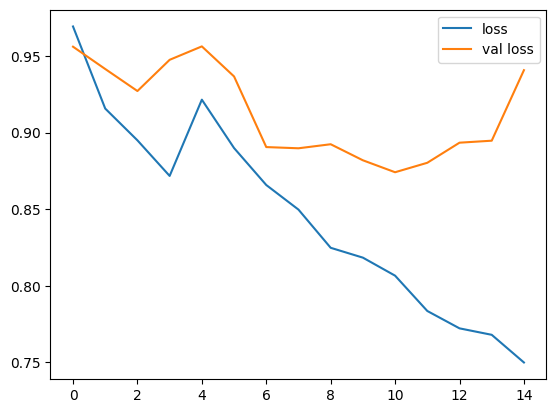

In [34]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val loss')
plt.legend()

In [35]:
# prompt: show accuracy based on test data

loss, accuracy = rnn.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


 7/37 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5891 - loss: 0.9381

2025-03-05 20:36:19.302804: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 20:36:19.303335: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6048 - loss: 0.9248
Test Accuracy: 0.597091555595398


In [36]:
history = rnn_at.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size = 64, epochs = 15)

Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5384 - loss: 0.9581

2025-03-05 20:36:27.511235: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 20:36:27.511546: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.5393 - loss: 0.9572 - val_accuracy: 0.5840 - val_loss: 0.9083
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.6105 - loss: 0.8588 - val_accuracy: 0.5968 - val_loss: 0.8752
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.6288 - loss: 0.8240 - val_accuracy: 0.6021 - val_loss: 0.8611
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.6379 - loss: 0.7964 - val_accuracy: 0.6214 - val_loss: 0.8055
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.6514 - loss: 0.7785 - val_accuracy: 0.6193 - val_loss: 0.8166
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.6705 - loss: 0.7443 - val_accuracy: 0.6289 - val_loss: 0.8149
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.6706 - loss: 0.7260 - val_accuracy: 0.6406 - val_loss: 0.7971
Epoch 8/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.6829 - loss: 0.6960 - val_accuracy: 0.6471 - val_

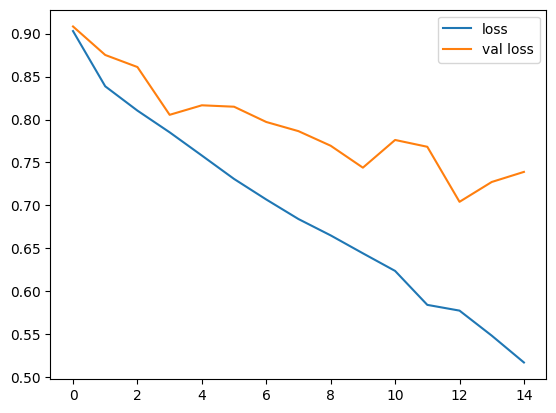

In [37]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val loss')
plt.legend()

In [38]:
loss, accuracy = rnn_at.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

 5/37 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6733 - loss: 0.8723

2025-03-05 20:38:18.853875: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 20:38:18.854175: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6966 - loss: 0.7593
Test Accuracy: 0.7065868377685547


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
[[ 63  76  33]
 [ 41 541  44]
 [ 27 122 222]]


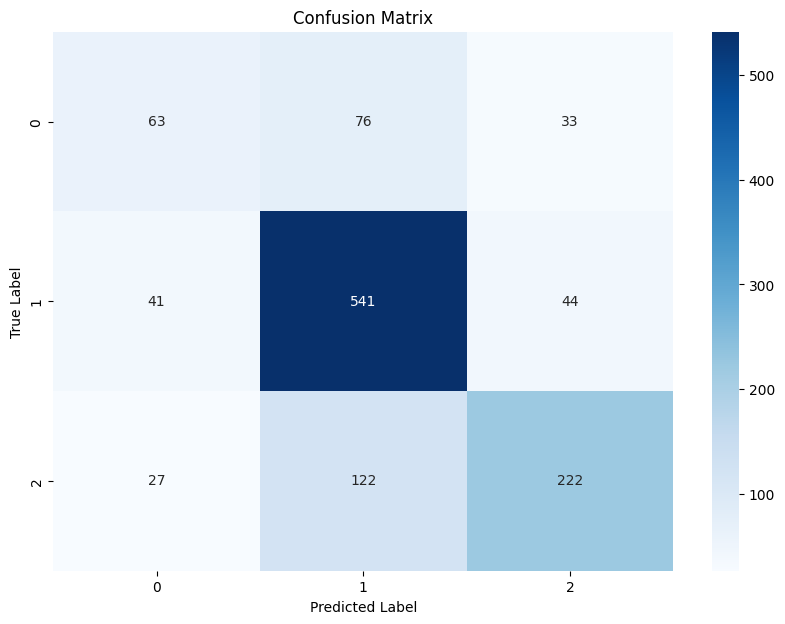

In [39]:
# Obtain predicted labels
y_pred = np.argmax(rnn_at.predict(X_test), axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1','2'], yticklabels=['0','1','2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [40]:
history = lstm.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size = 64, epochs = 15)

Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4951 - loss: 1.0692

2025-03-05 20:38:33.610897: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 20:38:33.611278: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step - accuracy: 0.4958 - loss: 1.0685 - val_accuracy: 0.5123 - val_loss: 0.9952
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - accuracy: 0.5297 - loss: 0.9770 - val_accuracy: 0.5102 - val_loss: 0.9129
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.5706 - loss: 0.8797 - val_accuracy: 0.5765 - val_loss: 0.8855
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.5871 - loss: 0.8557 - val_accuracy: 0.5936 - val_loss: 0.8755
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - accuracy: 0.6208 - loss: 0.8420 - val_accuracy: 0.6053 - val_loss: 0.8581
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - accuracy: 0.6378 - loss: 0.8293 - val_accuracy: 0.5979 - val_loss: 0.8675
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.6404 - loss: 0.8145 - val_accuracy: 0.6225 - val_loss: 0.8324
Epoch 8/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 263ms/step - accuracy: 0.6535 - loss: 0.7920 - val_accuracy: 0.637

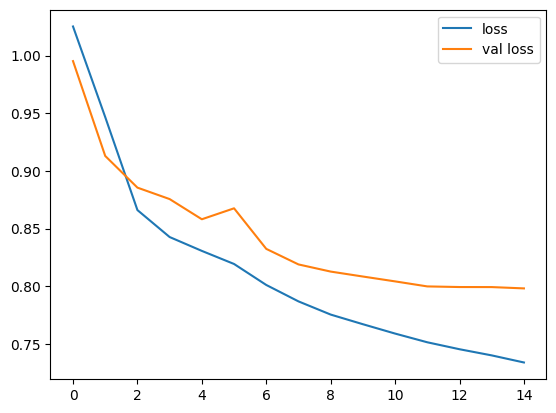

In [41]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val loss')
plt.legend()

In [42]:
loss, accuracy = lstm.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

 2/37 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6641 - loss: 0.7680

2025-03-05 20:41:36.905799: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 20:41:36.906126: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6628 - loss: 0.7777
Test Accuracy: 0.6569717526435852


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
[[  0  65 107]
 [  0 527  99]
 [  0 130 241]]


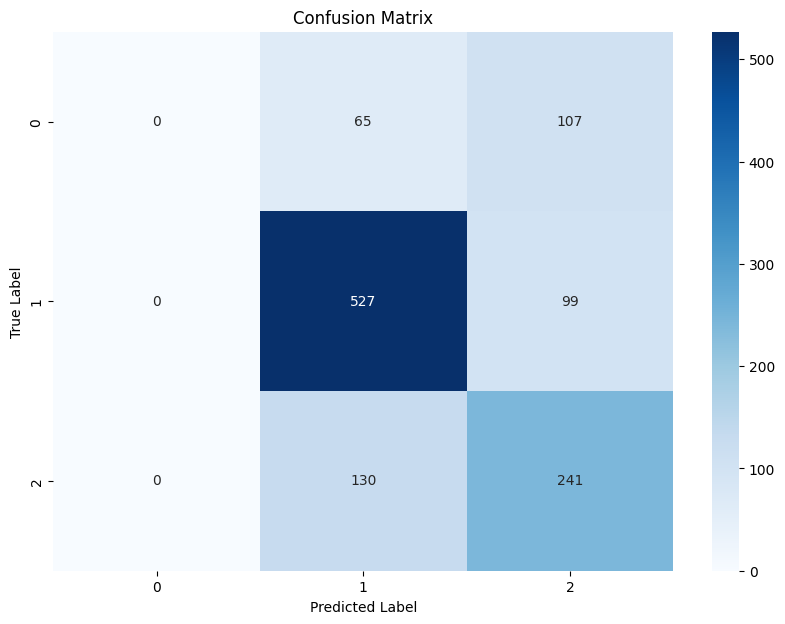

In [43]:
#Confusion matrix
y_pred = np.argmax(lstm.predict(X_test), axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1','2'], yticklabels=['0','1','2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [44]:
#add the confusion matrix and plot here for your lstm_at model

In [48]:
history = lstm_at.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size = 64, epochs = 15)

Epoch 1/15


2025-03-05 21:04:15.327156: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 21:04:15.327504: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7288 - loss: 0.6187

2025-03-05 21:04:28.185554: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 21:04:28.185849: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - accuracy: 0.7287 - loss: 0.6186 - val_accuracy: 0.6845 - val_loss: 0.7358
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.7300 - loss: 0.6046 - val_accuracy: 0.6888 - val_loss: 0.7326
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step - accuracy: 0.7318 - loss: 0.5910 - val_accuracy: 0.6930 - val_loss: 0.7297
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.7328 - loss: 0.5758 - val_accuracy: 0.6877 - val_loss: 0.7275
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step - accuracy: 0.7358 - loss: 0.5744 - val_accuracy: 0.6920 - val_loss: 0.7175
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 261ms/step - accuracy: 0.7449 - loss: 0.5632 - val_accuracy: 0.6813 - val_loss: 0.7319
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 262ms/step - accuracy: 0.7406 - loss: 0.5557 - val_accuracy: 0.6824 - val_loss: 0.7784
Epoch 8/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - accuracy: 0.7459 - loss: 0.5515 - val_accuracy: 0.675

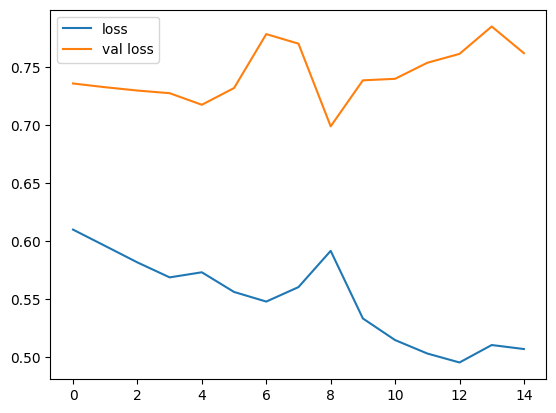

In [49]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val loss')
plt.legend()

In [50]:
loss, accuracy = lstm_at.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

 2/37 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.6016 - loss: 0.8428

2025-03-05 21:08:41.037349: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-03-05 21:08:41.037693: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6772 - loss: 0.7622
Test Accuracy: 0.6869118809700012


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
[[ 73  46  53]
 [ 52 458 116]
 [ 26  73 272]]


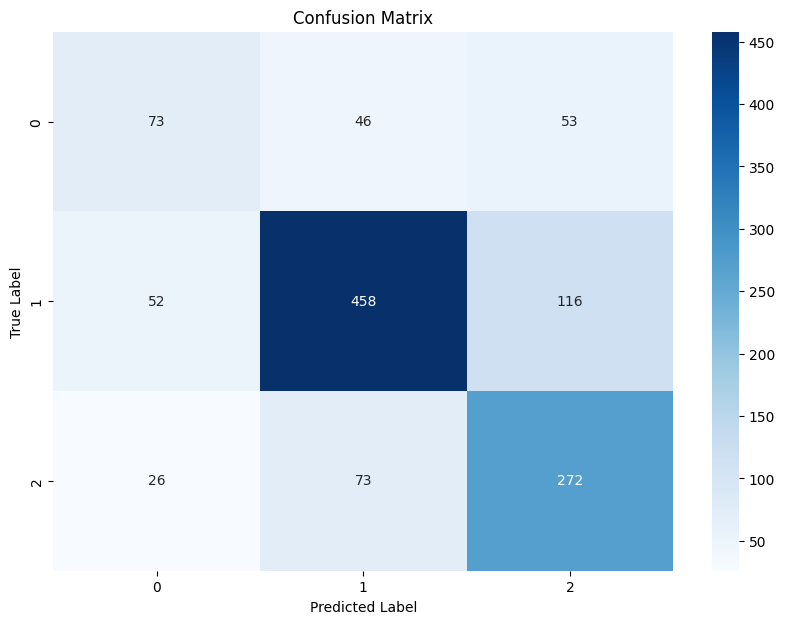

In [51]:
#Confusion matrix
y_pred = np.argmax(lstm_at.predict(X_test), axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1','2'], yticklabels=['0','1','2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#[Step 4] **DISCUSS**:
* Compare RNN with LSTM, do you see the difference in performance? Why did LSTM do better in prediction sentiment?

* How do you see the results change after adding the attention layer? Where does the benefit of attention come from?


# Acknowledgement

**Acknowledge**

https://www.kaggle.com/code/azzamradman/04-dl-nlp-part-1/notebook

**dataset citation**

Malo, Pekka, et al. "Good debt or bad debt: Detecting semantic orientations in economic texts." Journal of the Association for Information Science and Technology 65.4 (2014): 782-796.
